Instalacja bibliotek ML

In [40]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", 
                "scikit-learn", "seaborn", "requests"])
!pip install mp-api

Import bibliotek

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

Pobieranie danych z MaterialsProject

In [42]:
from mp_api.client import MPRester

API_KEY = "N2QGflniDc1arUXJVS5KmBmnjLnEwsE0"

with MPRester(API_KEY) as mpr:
    results = mpr.materials.summary.search(
        fields=["material_id", "formula_pretty", "band_gap", "density", "volume", "nsites"],
        num_chunks=10
    )

print(f"Pobrano rekordów: {len(results)}")

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Pobrano rekordów: 10000


In [43]:
df = pd.DataFrame([{
    "material_id": str(r.material_id),
    "formula": r.formula_pretty,
    "band_gap": r.band_gap,
    "density": r.density,
    "volume": r.volume,
    "nsites": r.nsites
} for r in results])

print(f"Rozmiar danych: {df.shape}")  # liczba wierszy i kolumn
df.head()

Rozmiar danych: (10000, 6)


,material_id,formula,band_gap,density,volume,nsites
0,mp-1197903,C,0.0797,1.030997,1547.569425,80
1,mp-1094120,Nb,0.0000,8.161256,226.839615,12
2,mp-1179802,Rb,0.0000,1.525036,744.494598,8
3,mp-1244933,Si,0.0000,2.599954,1793.764938,100
4,mp-1244964,C,0.0724,1.769793,1126.924923,100


Zapisanie danych lokalnie

In [44]:
df.to_csv("materials_data.csv", index=False)
print("Dane zapisane")

Dane zapisane


Informacje o danych

In [45]:
print(df.info())
print("\nStatystyki:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   material_id  10000 non-null  object 
 1   formula      10000 non-null  object 
 2   band_gap     10000 non-null  float64
 3   density      10000 non-null  float64
 4   volume       10000 non-null  float64
 5   nsites       10000 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 468.9+ KB
None

Statystyki:


,band_gap,density,volume,nsites
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.552967,6.157396,420.199198,19.262700
std,1.321564,3.853006,676.537830,27.937161
min,0.000000,0.023670,5.610269,1.000000
25%,0.000000,3.069802,88.116893,4.000000
50%,0.000000,5.427865,178.659562,8.000000
75%,0.161550,8.310274,428.502214,20.000000
max,17.891400,26.581336,10887.909463,360.000000


EDA (ekploracyjna analiza danych)

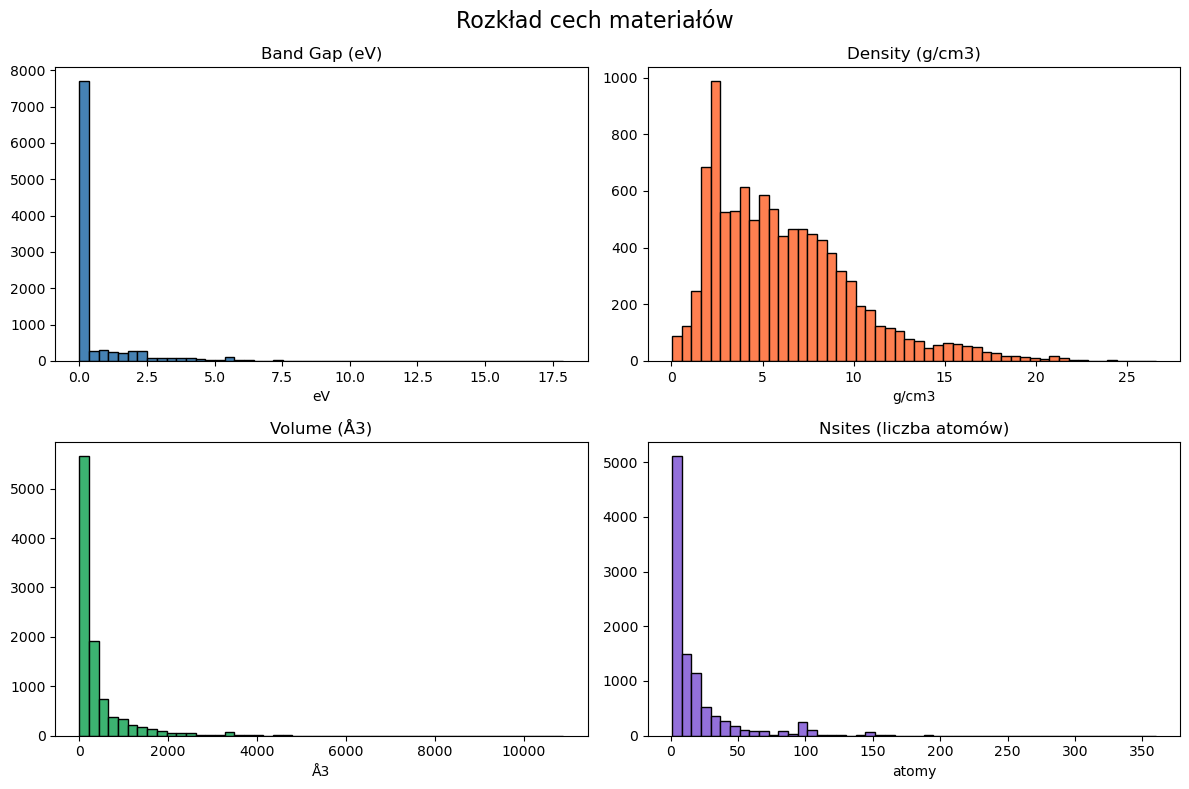

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # 4 wykresy - rozlokowanie 2 nad 2 
fig.suptitle("Rozkład cech materiałów", fontsize=16)

# Rozkład band_gap
axes[0,0].hist(df["band_gap"], bins=50, color="steelblue", edgecolor="black")
axes[0,0].set_title("Band Gap (eV)")
axes[0,0].set_xlabel("eV")

# Rozkład density
axes[0,1].hist(df["density"], bins=50, color="coral", edgecolor="black")
axes[0,1].set_title("Density (g/cm3)")
axes[0,1].set_xlabel("g/cm3")

# Rozkład volume
axes[1,0].hist(df["volume"], bins=50, color="mediumseagreen", edgecolor="black")
axes[1,0].set_title("Volume (Å3)")
axes[1,0].set_xlabel("Å3")

# Rozkład nsites
axes[1,1].hist(df["nsites"], bins=50, color="mediumpurple", edgecolor="black")
axes[1,1].set_title("Nsites (liczba atomów)")
axes[1,1].set_xlabel("atomy")

plt.tight_layout()
plt.show()

Korelacje między cechami

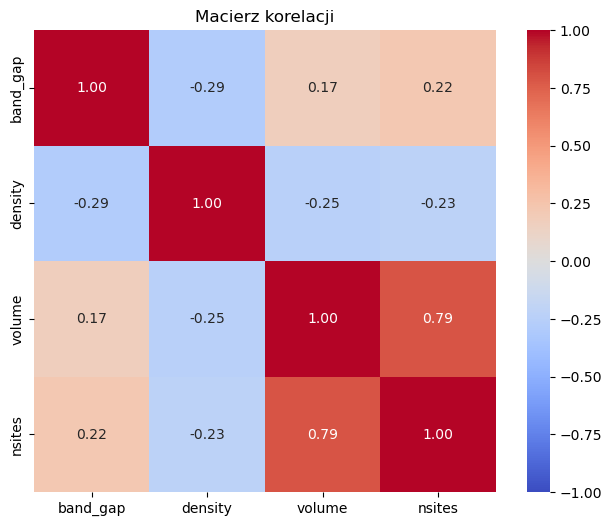

In [47]:
# Wybór tylko kolumn numerycznych
numeric_cols = ["band_gap", "density", "volume", "nsites"]

# Macierz korelacji
correlation_matrix = df[numeric_cols].corr()

# Wykres
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True, # pokazuje wartości liczbowe
    fmt=".2f", # format do 2 miejsc po przecinku
    cmap="coolwarm", # paleta kolorów (niebieski=ujemna, czerwony=dodatnia)
    vmin=-1, vmax=1, # skala od -1 do 1
    square=True # kwadratowe komórki
)
plt.title("Macierz korelacji")
plt.show()

- im gęstszy materiał, tym mniejsza przerwa energetyczna (zgadza się z metalami: przerwa = 0 eV i duża gęstość)

Wybór modelu:
- słabe korelacje z band_gap (zależności nieliniowe/skomplikowane), więc linear regression będzie raczej słabe
- random forest and grandient boosting - mogą być lepsze

Sprawdzenie brakujących wartości

In [48]:
print("Brakujące wartości:")
print(df.isnull().sum())

print(f"\nProcent materiałów z band_gap = 0 (metale):")
metals = (df["band_gap"] == 0).sum()
print(f"{metals} / {len(df)} = {metals/len(df)*100:.1f}%")

Brakujące wartości:
material_id    0
formula        0
band_gap       0
density        0
volume         0
nsites         0
dtype: int64

Procent materiałów z band_gap = 0 (metale):
7187 / 10000 = 71.9%


Filtrowanie tylko materiałów z band_gap > 0 (półprzewodniki i izolatory)

In [49]:
df_filtered = df[df["band_gap"] > 0].copy()

print(f"Przed filtrowaniem: {len(df)} materiałów")
print(f"Po filtrowaniu: {len(df_filtered)} materiałów")
print(f"\nStatystyki band_gap po filtrowaniu:")
print(df_filtered["band_gap"].describe())

Przed filtrowaniem: 10000 materiałów
Po filtrowaniu: 2813 materiałów

Statystyki band_gap po filtrowaniu:
count    2813.000000
mean        1.965754
std         1.852618
min         0.000100
25%         0.587900
50%         1.531400
75%         2.562000
max        17.891400
Name: band_gap, dtype: float64


Feature engineering i normalizacja

In [50]:
# Wybranie cech (X) i celu (y)
features = ["density", "volume", "nsites"]
target = "band_gap"

X = df_filtered[features] # tabela cech wejściowych
y = df_filtered[target] # kolumna, którą przewidujemy

# Normalizacja (skalowanie cech do podobnego zakresu)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
    test_size=0.2, # 20% na testy
    random_state=42 # dla powtarzalności wyników
)
print(f"Rozmiar X (cechy): {X.shape}")
print(f"Rozmiar y (cel): {y.shape}")
print(f"\nPierwsze 5 wierszy X:")
print(f"Zbiór treningowy: {X_train.shape[0]} materiałów")
print(f"Zbiór testowy: {X_test.shape[0]} materiałów")
X.head()

Rozmiar X (cechy): (2813, 3)
Rozmiar y (cel): (2813,)

Pierwsze 5 wierszy X:
Zbiór treningowy: 2250 materiałów
Zbiór testowy: 563 materiałów


,density,volume,nsites
0,1.030997,1547.569425,80
4,1.769793,1126.924923,100
6,1.598453,199.450062,12
8,2.427656,1921.073773,100
10,1.675489,1190.353192,100


Trenowanie modeli

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Definicja modeli
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Trenowanie i ewaluacja
results = {}
for name, model in models.items():
    # Trenowanie
    model.fit(X_train, y_train)
    
    # Przewidywanie
    y_pred = model.predict(X_test)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results[name] = {"RMSE": rmse, "CV RMSE": cv_rmse}
    print(f"{name}:")
    print(f" RMSE: {rmse:.4f}")
    print(f" CV RMSE: {cv_rmse:.4f}")
    print()

Linear Regression:
 RMSE: 1.8113
 CV RMSE: 1.7919

Random Forest:
 RMSE: 1.6315
 CV RMSE: 1.6970

Gradient Boosting:
 RMSE: 1.6904
 CV RMSE: 1.7183



Feature impoartance

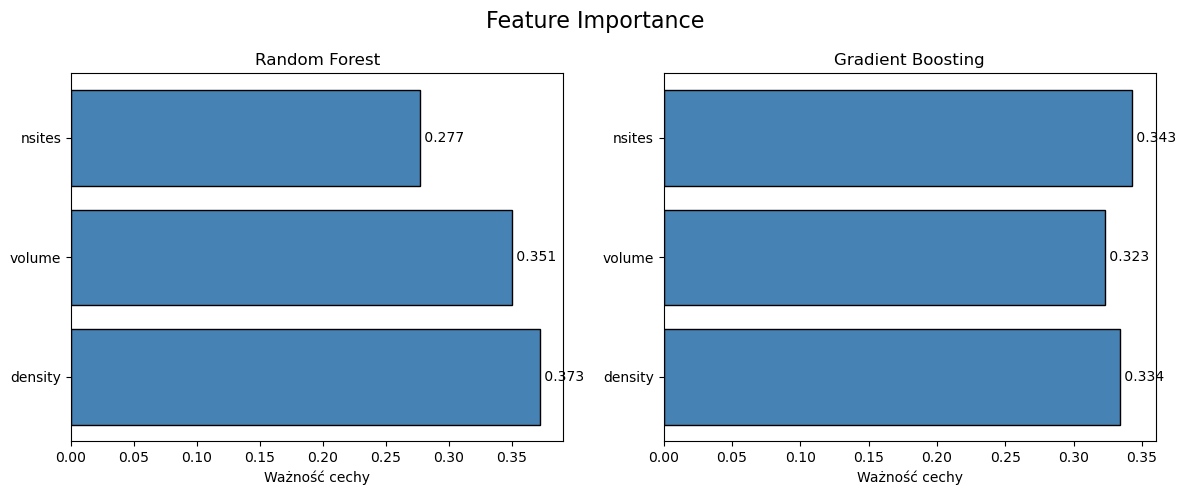

In [52]:
# Feature importance dla random forest i gradient boosting (linear regression odrzucone)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Feature Importance", fontsize=16)

# Random Forest
importance_rf = models["Random Forest"].feature_importances_

axes[0].barh(features, importance_rf, color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Ważność cechy")
for i, v in enumerate(importance_rf): # etykieta przy słupku (i - numer cechy, v - wartość ważności)
    axes[0].text(v, i, f" {v:.3f}", va="center")

# Gradient Boosting
importance_gb = models["Gradient Boosting"].feature_importances_

axes[1].barh(features, importance_gb, color="steelblue", edgecolor="black")
axes[1].set_title("Gradient Boosting")
axes[1].set_xlabel("Ważność cechy")
for i, v in enumerate(importance_gb):
    axes[1].text(v, i, f" {v:.3f}", va="center")

plt.tight_layout()
plt.show()

Niejednoznaczne dane (różnica w określeniu najważważniejszej cechy dla struktury elektronowej w zależności od modelu) --> sprawdzenie średniej ważności z obu modeli

Średnia ważność

In [53]:
rf_importance = models["Random Forest"].feature_importances_
gb_importance = models["Gradient Boosting"].feature_importances_
avg_importance = (rf_importance + gb_importance)/2

for feat, imp in zip(features, avg_importance):
    print(f"{feat}: {imp:.3f}")

density: 0.353
volume: 0.337
nsites: 0.310


- nie ma wielkiej dominacji żadnej z cech nad innymi --> wszystkie 3 są istotne